### Part 2 of the Thesis

Usage of sliding windows to filter other detections instead of only focusing on top RE events.

In [1]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions import training_lib as tl
from helperfunctions.preprocessing import PreprocessingStep5
from helperfunctions.detection import Part2 as p2
from torch import nn
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple
import numpy as np
import os
from glob import glob
#%matplotlib widget
%matplotlib inline
pd.set_option("display.max_columns", None)

In [2]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)


{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

In [3]:
test_eval_file = glob(os.path.join(ic.PATH_PART2_EVAL_TEST, "*.csv")) [0]
test_eval_df = pd.read_csv(test_eval_file)

display(test_eval_df.head())

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1588306200000000001,2020-05-01 04:10:00,1,0.021798,0.008148,0.094487,0.020666,0.021166,0.002876,0.011175,0.003134,0.002139,0.083261,0.000055,0.000006,0.006936,0.027010,2.388245e-01,0.002420,0.000163,0.001425,0.001798,1.648817e-06,1.111275e-02,0.002902,0.002989,0.003100,0.018406,0.000058,0.000525,0.002179,0.002669,0.002781,0.001968,0.000169,0.004524,0.000044,0.000239,0.012340,0.000073,0.000367,0.236192
1,1588306200000000002,2020-05-01 04:10:00,2,0.026611,0.005555,0.147881,0.003152,0.005707,0.000037,0.000812,0.001665,0.000005,0.008374,0.000661,0.001424,0.000864,0.001743,2.390153e-01,0.006600,0.005054,0.180388,0.000170,2.252205e-03,1.640601e-02,0.002016,0.003590,0.003878,0.027006,0.000309,0.002825,0.000692,0.000909,0.000992,0.014479,0.004077,0.037727,0.014320,0.001727,0.014470,0.003942,0.013449,0.237053
2,1588306200000000004,2020-05-01 04:10:00,4,0.002452,0.000042,0.000007,0.002139,0.001538,0.000092,0.000897,0.000340,0.000293,0.026001,0.000186,0.000001,0.001525,0.000315,9.567735e-05,0.038999,0.002810,0.001857,0.000648,1.571099e-09,1.076651e-07,0.000094,0.000615,0.000009,0.000876,0.000004,0.001630,0.000468,0.000294,0.000284,0.000529,0.000318,0.003309,0.000072,0.000651,0.005969,0.000130,0.000011,0.000130
3,1588306200000000005,2020-05-01 04:10:00,5,0.013120,0.005832,0.035099,0.013446,0.022986,0.000044,0.008692,0.004631,0.000002,0.000229,0.014190,0.004403,0.012072,0.003371,4.101939e-05,0.005850,0.001402,0.003673,0.000112,9.969746e-04,5.928122e-05,0.000172,0.000108,0.000001,0.000500,0.249002,0.008641,0.000214,0.000377,0.000418,0.002332,0.004244,0.015442,0.001185,0.018634,0.051762,0.007190,0.001146,0.000083
4,1588306200000000006,2020-05-01 04:10:00,6,0.013144,0.000221,0.043485,0.000567,0.001858,0.005117,0.000530,0.010470,0.001455,0.000081,0.000861,0.000829,0.000894,0.003858,2.060028e-08,0.005266,0.004495,0.000031,0.000075,1.441789e-03,1.015547e-02,0.047146,0.044287,0.046548,0.017712,0.236755,0.001082,0.001290,0.001459,0.000232,0.000188,0.000374,0.001174,0.001621,0.000152,0.001344,0.002955,0.003236,0.000237


In [432]:
test_eval_clean = p2.drop_imputations(test_eval_df)

In [433]:
test_raw_df = pd.read_csv(ic.PATH_PART2_RAW_TEST / "raw_test.csv")

In [434]:
test_raw_clean = p2.drop_imputations(test_raw_df)

In [399]:
theta = p2.load_threshold_table()

   WT_ID    k     sigma  threshold   tp   fn     fp  precision  recall  \
0      1  1.0  0.029094    0.04219  7.0  1.0  236.0   0.028807   0.875   

         f1  FAR_per_day  latency_mean  
0  0.055777     1.594595    111.714286  


### Power Curve 

In [6]:
pre_step5 = PreprocessingStep5()
df_pc = pre_step5._prepare_power_curve()
df_pc.head()

,power_norm
0.00,0.0
0.01,0.0
0.02,0.0
0.03,0.0
0.04,0.0


In [7]:

test_start = cfg_part2.test_start_time
test_end = cfg_part2.test_end_time

wt_farm_df = pd.read_csv(ic.PATH_PART2_WT_FARM /  "wt_farm_pc_df.csv")
wt_farm_df[ic.TS_COL] = pd.to_datetime(wt_farm_df[ic.TS_COL])
wt_farm_df.head()

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,1,2020-05-01 04:10:00,5.180120,154.845861
1,1,2020-05-01 04:20:00,4.917112,125.039087
2,1,2020-05-01 04:30:00,5.379890,151.489965
3,1,2020-05-01 04:40:00,4.659290,100.066924
4,1,2020-05-01 04:50:00,5.240885,117.778430


### new


In [253]:
catalog_df = pd.read_csv(ic.PATH_PART2_DETECTIONS / "catalog.csv")

In [254]:
display(catalog_df.head())
len(catalog_df)

,WT_ID,re_at_ts,Date and time,signal_name,window_start,window_end,wind_center,n_baseline,mean_baseline,std_baseline,mean_event,std_event,value_at_ts,delta_at_ts,z_at_ts,delta_mean,z_shift,flag_sig_shift_event_mean
0,1,0.614519,2020-11-30 07:00:00,Gear oil inlet pressure (bar),2020-11-25 06:30:00,2020-12-05 08:10:00,12.5,0,NaN,NaN,215.710967,61.643639,305.812871,NaN,NaN,NaN,NaN,False
1,1,0.611402,2020-11-30 07:00:00,Gear oil pump pressure (bar),2020-11-25 06:30:00,2020-12-05 08:10:00,12.5,0,NaN,NaN,627.888345,153.324231,855.413843,NaN,NaN,NaN,NaN,False
2,1,0.596408,2021-11-27 12:30:00,Motor current axis 3 (A),2021-11-21 14:10:00,2021-12-02 14:10:00,22.5,0,NaN,NaN,2.668810,1.752759,5.199837,NaN,NaN,NaN,NaN,False
3,1,0.587252,2021-02-04 21:40:00,Gear oil pump pressure (bar),2021-01-30 16:30:00,2021-02-09 21:10:00,13.5,0,NaN,NaN,759.200561,101.173315,848.125216,NaN,NaN,NaN,NaN,False
4,1,0.575485,2021-02-04 21:40:00,Gear oil inlet pressure (bar),2021-01-30 16:30:00,2021-02-09 21:10:00,13.5,0,NaN,NaN,265.991428,33.025694,298.759744,NaN,NaN,NaN,NaN,False


780

In [235]:
catalog_df = p2.drop_imputations(catalog_df)
len(catalog_df)

630

In [435]:
display(test_raw_clean.head())

,Unnamed: 0,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW),Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
0,96166,1,8.886364,2018-04-05 13:50:00,84.215630,222.195496,614.294067,1775.618774,35.227272,38.127274,1774.221191,12.000000,-0.239751,-0.539216,0.579323,7.145454,265.389313,16.813637,1050.261230,28.177273,16.867664,61.836365,23.695456,48.168182,51.031818,48.636364,-4.109046,259.431061,8.432441,0.000000,0.000,0.000000,71.868179,49.604546,58.040909,63.022728,44.158005,16.394218,11.000000,43.190907,265.389313
1,96167,1,9.020000,2018-04-05 14:00:00,83.337074,211.881287,588.308411,1716.233887,37.028332,39.248333,1715.009521,12.000000,0.212582,0.021242,1.167647,7.320000,258.657104,17.543333,864.163757,28.320000,16.295387,64.084999,23.710001,44.291332,47.303333,44.805668,-3.752453,253.765579,8.332128,0.018000,0.018,0.017333,72.098335,50.856667,58.200001,63.035000,46.899048,26.877043,11.300000,43.434998,258.657104
2,96168,1,9.300000,2018-04-05 14:10:00,92.407433,200.020737,552.660828,1715.237671,37.798275,39.627586,1714.197266,12.000000,-0.373563,-0.516058,0.545639,7.410345,252.218536,14.820689,888.429932,28.382759,16.295769,64.739655,23.844828,39.965519,42.463104,40.479309,3.593682,254.095566,8.278221,0.000000,0.000,0.000000,73.525864,55.715519,59.391380,63.956898,51.394279,19.161951,11.413793,43.384483,252.218536
3,96169,1,9.216667,2018-04-05 14:20:00,90.661583,267.993591,763.333496,1707.441406,36.098331,38.843334,1706.402832,12.000000,-0.234967,0.023529,0.651307,7.241667,246.889282,13.206667,881.109497,28.308334,16.210365,61.603333,23.671667,37.166668,39.389668,37.599998,-2.304303,244.534927,8.351465,0.002333,0.002,0.002667,71.198334,36.943333,57.778332,62.551666,51.467808,27.534857,11.413334,43.491665,246.889282
4,96170,1,9.220000,2018-04-05 14:30:00,85.227211,254.927795,709.947754,1726.104004,34.810001,37.741665,1724.966187,12.033667,-0.490196,-0.490196,0.490196,7.216667,240.986282,14.205000,861.777832,28.326666,16.406225,59.398335,23.498333,35.400002,37.400002,35.833332,6.911681,248.549179,8.123881,0.000000,0.000,0.000000,67.166664,38.938332,55.606667,59.930000,41.149757,22.395346,11.423333,43.511665,240.994415


In [609]:
excl_wts = {1,2,4}

In [610]:
filtered_cat = test_raw_clean[(test_raw_clean["Power (kW)"] >= 2000) & (test_raw_clean[ic.TS_COL] >= cfg_part2.test_start_time)]
filtered_cat = filtered_cat[~filtered_cat[ic.WT_ID].isin(excl_wts)]
display(filtered_cat.head())
display(filtered_cat[ic.WT_ID].unique())

,Unnamed: 0,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW),Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
779635,1241037,5,15.893333,2020-05-09 20:10:00,6.736618,232.970680,651.161365,1802.239811,46.786666,43.261667,1798.868790,23.000000,3.159314,3.858497,3.039542,9.486667,8.330871,21.485000,2005.743766,27.833333,17.118379,68.630000,27.415000,60.871667,63.500000,62.566667,1.590442,10.166485,13.704126,5.111000,5.123000,5.122333,73.778334,49.688334,57.851667,65.280001,63.963283,34.389898,17.561666,42.311666,8.341600
779636,1241038,5,14.968334,2020-05-09 20:20:00,9.849283,298.194656,821.528451,1800.325191,47.483333,43.093333,1797.184189,23.000000,3.383333,3.700653,3.497222,8.888333,17.583818,17.513333,2034.885726,28.288334,17.098903,74.788334,27.048334,69.373000,72.420333,71.402333,0.604133,16.817601,12.757716,4.658667,4.658333,4.656000,72.820000,29.958333,56.586666,64.268334,44.543140,36.777432,16.621666,47.631666,17.583818
779638,1241040,5,13.675000,2020-05-09 20:40:00,7.431676,301.544010,829.670449,1801.557827,46.446666,42.963333,1798.255924,23.000000,3.191340,3.684804,3.757189,8.608333,14.905801,15.285000,2032.121981,28.861666,17.118364,78.513333,25.845000,74.673000,77.498000,76.533333,-6.205386,9.380057,13.181091,4.185667,4.188333,4.187667,69.398332,28.308333,55.091667,62.868334,38.928042,51.069066,15.860000,56.755000,14.895571
779643,1241045,5,12.140000,2020-05-09 21:30:00,8.743165,299.186696,829.568309,1801.198048,42.406666,42.260000,1798.123665,22.527667,3.576144,4.086274,3.762582,7.398333,9.365745,13.505000,2026.761035,29.121667,17.116306,78.521667,22.675000,81.000000,83.466667,82.716667,-2.896382,7.407827,13.200455,5.420667,5.418667,5.420000,72.786666,31.181667,57.208333,64.615000,42.618205,44.229348,15.070000,69.630000,9.363184
779650,1241052,5,11.498333,2020-05-09 22:40:00,8.243999,269.249715,752.915432,1802.462063,39.240000,40.681666,1799.857014,22.000000,3.237582,4.846405,3.970425,6.881667,16.408175,12.903334,2042.424898,28.911666,17.137175,75.368334,21.135001,81.408333,83.654000,82.843000,0.509623,17.947084,13.163406,4.945000,4.939000,4.938333,73.921667,39.901667,58.200000,65.580000,47.444227,44.214548,14.735000,76.298333,16.416987


array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15], dtype=int64)

In [643]:
ts = "2020-05-22 10:40:00"
wt = 5

In [645]:
filtered_cat = test_raw_clean[(test_raw_clean[ic.TS_COL] == ts) & (test_raw_clean[ic.WT_ID] == wt)]
display(filtered_cat.head())

,Unnamed: 0,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW),Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
781447,1242852,5,19.47,2020-05-22 10:40:00,14.644053,271.601231,781.311668,1792.787281,40.578333,50.249999,1788.564747,22.0,3.16585,3.622712,2.761111,13.508333,205.265686,18.738334,1900.345276,32.148334,17.025077,88.368333,25.0,76.593333,86.0,67.461667,2.994751,208.951611,15.279276,9.147667,9.153333,9.151,71.876668,31.371667,55.36,63.388333,109.244287,59.277859,22.708333,96.955,205.265686


In [646]:
detection_ts  = pd.to_datetime(ts)

In [647]:
anom_span = [(detection_ts - pd.Timedelta(days=5), detection_ts + pd.Timedelta(days=5))]

In [648]:
print(detection_ts)
print(wt)
print(anom_span)

2020-05-22 10:40:00
5
[(Timestamp('2020-05-17 10:40:00'), Timestamp('2020-05-27 10:40:00'))]


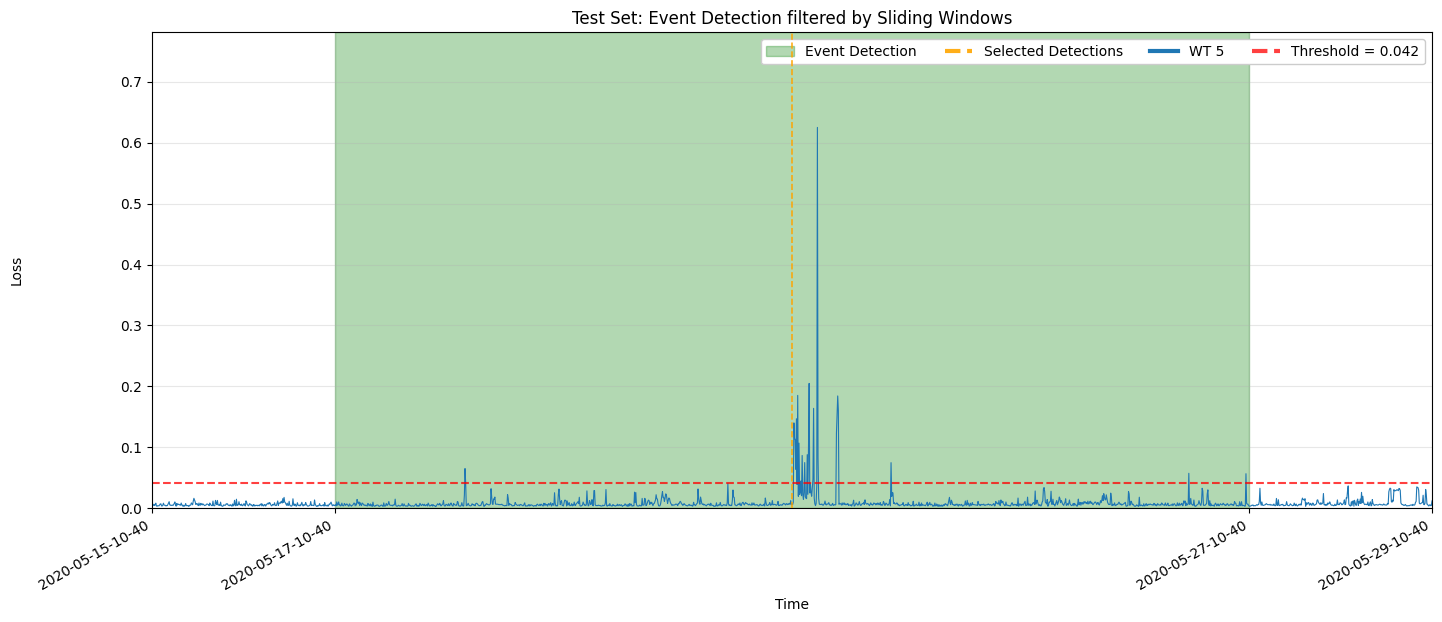

In [649]:
pp.print_loss(test_eval_df,
              dpi=300,
              #y_limits=((0,0.4),(0.4,100)),
              title=f"Test Set: Event Detection filtered by Sliding Windows",
              wt_id= [wt],
              ts_range=(detection_ts- pd.Timedelta(days=7),detection_ts + pd.Timedelta(days=7)),
              anomaly_spans=anom_span,
              mark_threshold=theta,
              anom_span_label="Event Detection",
              detection_ts=[detection_ts],
              
              )

In [650]:
top_signals_wt = p2.get_top_sigs_for_detections(
    eval_df=p2.drop_imputations(test_eval_df),
    selected_detections=filtered_cat.iloc[[0]],
    wt_id=wt,
    top_n_signals=5
)

print(top_signals_wt)

[(Timestamp('2020-05-22 10:40:00'), ['RE_Wind speed (m/s)', 'RE_Drive train acceleration (mm/ss)', 'RE_Ambient temperature (converter) (°C)', 'RE_Gear oil inlet temperature (°C)', 'RE_Hub temperature (°C)'])]


In [651]:
filtered_cat[ic.TS_COL] = pd.to_datetime(filtered_cat[ic.TS_COL])

C:\Users\admin\AppData\Local\Temp\ipykernel_16528\3640883847.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_cat[ic.TS_COL] = pd.to_datetime(filtered_cat[ic.TS_COL])


In [652]:
wt_windows = filtered_cat[(filtered_cat[ic.WT_ID] == wt)  & (filtered_cat[ic.TS_COL] == detection_ts)].iloc[[0]]
display(wt_windows)
anomaly_spans_wt = [(detection_ts - pd.Timedelta(days=5), detection_ts + pd.Timedelta(days=5))]
anomaly_spans_wt = sorted(anomaly_spans_wt, key=lambda span: span[0])
print(anomaly_spans_wt)
min_ts = anomaly_spans_wt[0][0]
max_ts = anomaly_spans_wt[-1][1]

,Unnamed: 0,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW),Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
781447,1242852,5,19.47,2020-05-22 10:40:00,14.644053,271.601231,781.311668,1792.787281,40.578333,50.249999,1788.564747,22.0,3.16585,3.622712,2.761111,13.508333,205.265686,18.738334,1900.345276,32.148334,17.025077,88.368333,25.0,76.593333,86.0,67.461667,2.994751,208.951611,15.279276,9.147667,9.153333,9.151,71.876668,31.371667,55.36,63.388333,109.244287,59.277859,22.708333,96.955,205.265686


[(Timestamp('2020-05-17 10:40:00'), Timestamp('2020-05-27 10:40:00'))]


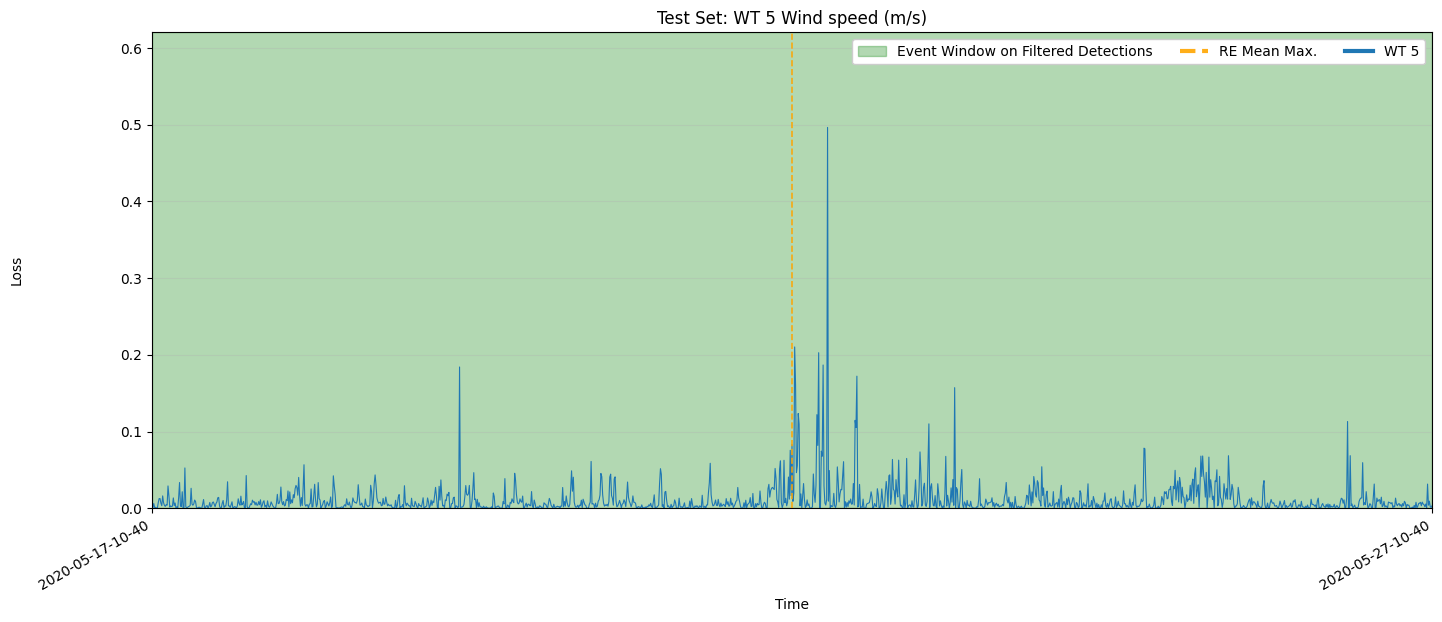

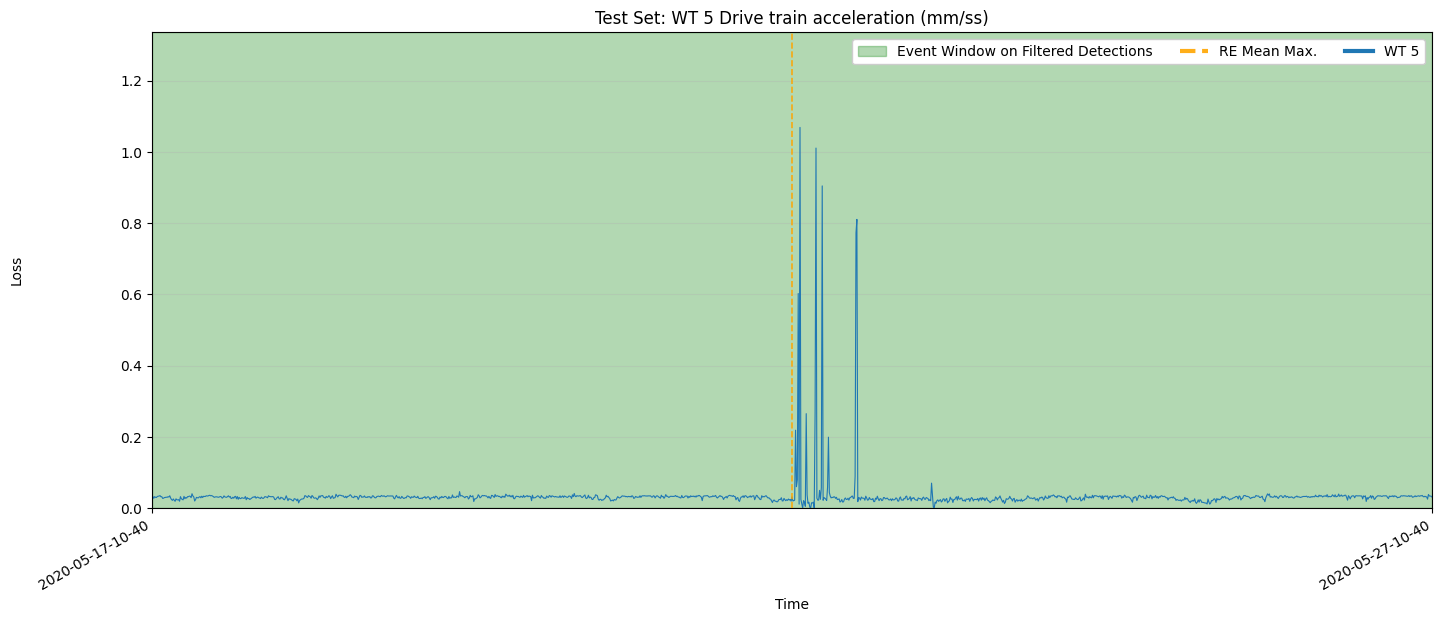

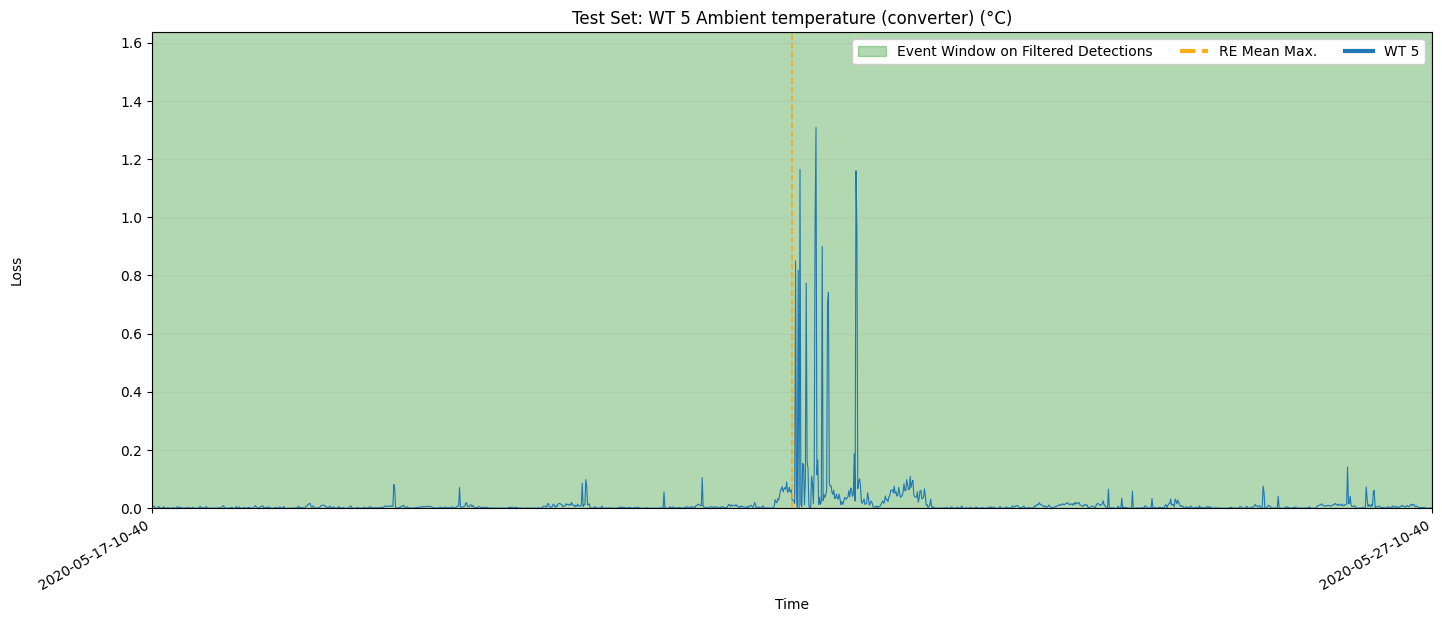

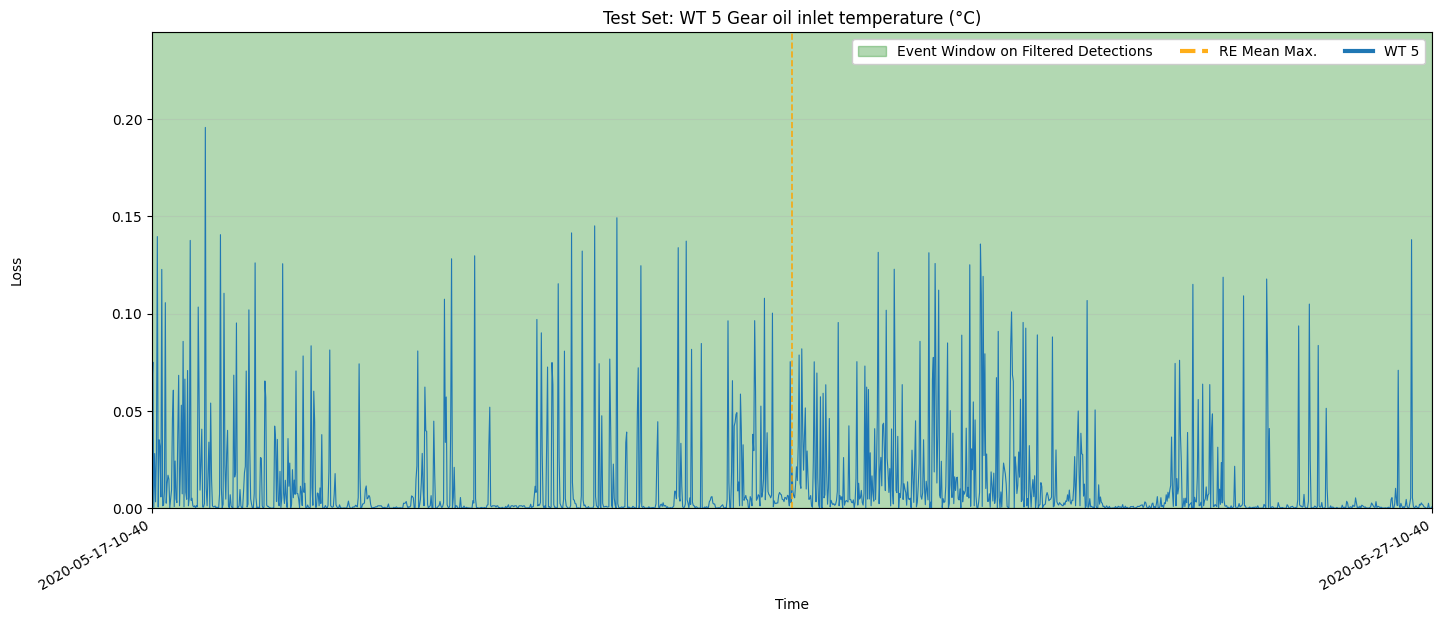

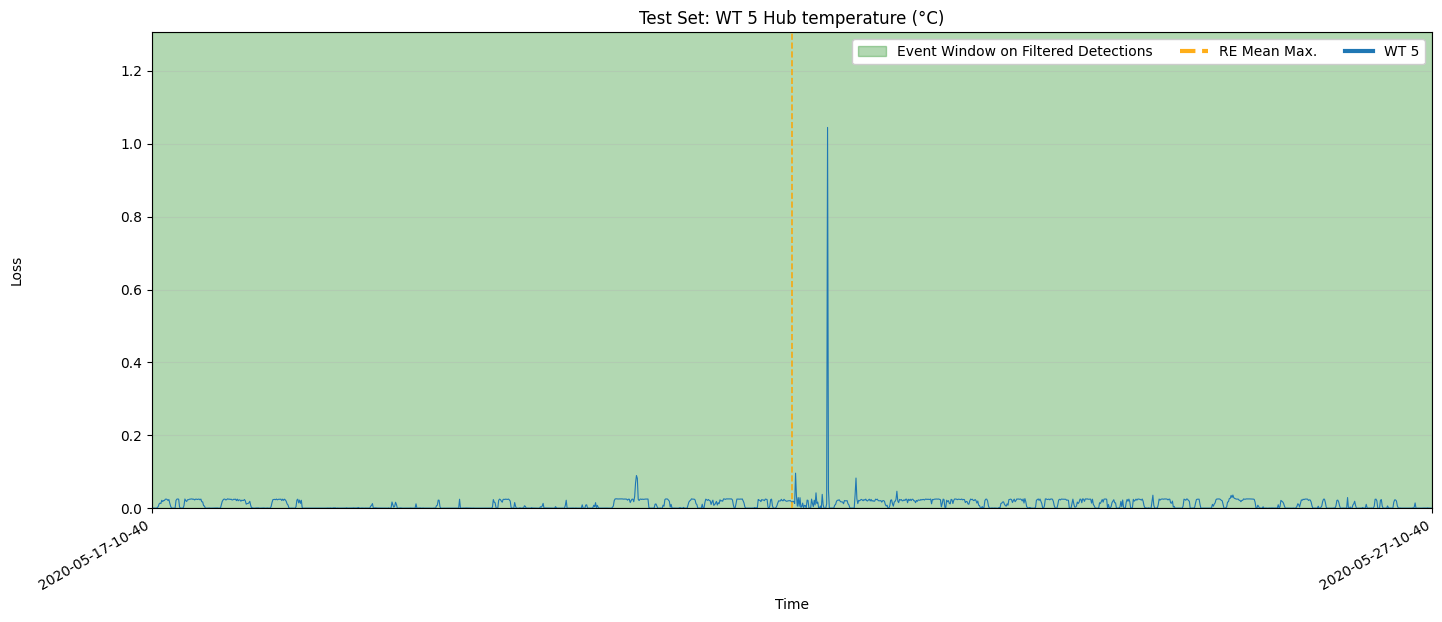

In [653]:
for idx,(ts,sig_list) in enumerate(top_signals_wt):
    for sig in sig_list:
        pp.print_loss(test_eval_df,
                    dpi=300,
                    #y_limits=((0,0.5),(0.5,700)),
                    title=f"Test Set: WT {wt} {sig[3:]}",
                    wt_id= [wt],
                    values=sig,
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=[anomaly_spans_wt[0]],
                    mark_threshold=None,
                    anom_span_label="Event Window on Filtered Detections",
                    detection_ts=[ts],
                    detection_label="RE Mean Max."
                    )

In [654]:
top_sigs_no_prefix_wt = [(ts, sig[3:]) for sig in sig_list  for (ts,sig_list) in top_signals_wt]
print(top_sigs_no_prefix_wt)

[(Timestamp('2020-05-22 10:40:00'), 'Wind speed (m/s)'), (Timestamp('2020-05-22 10:40:00'), 'Drive train acceleration (mm/ss)'), (Timestamp('2020-05-22 10:40:00'), 'Ambient temperature (converter) (°C)'), (Timestamp('2020-05-22 10:40:00'), 'Gear oil inlet temperature (°C)'), (Timestamp('2020-05-22 10:40:00'), 'Hub temperature (°C)')]


In [655]:
print(wt)

5


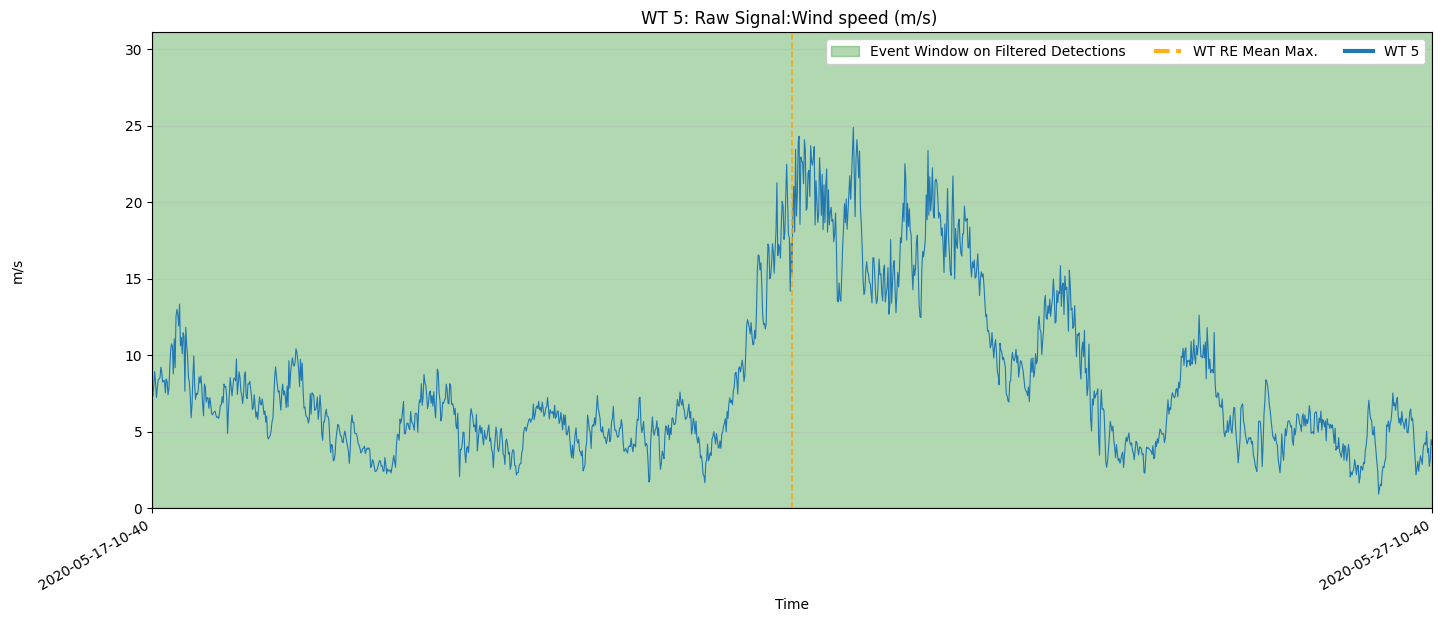

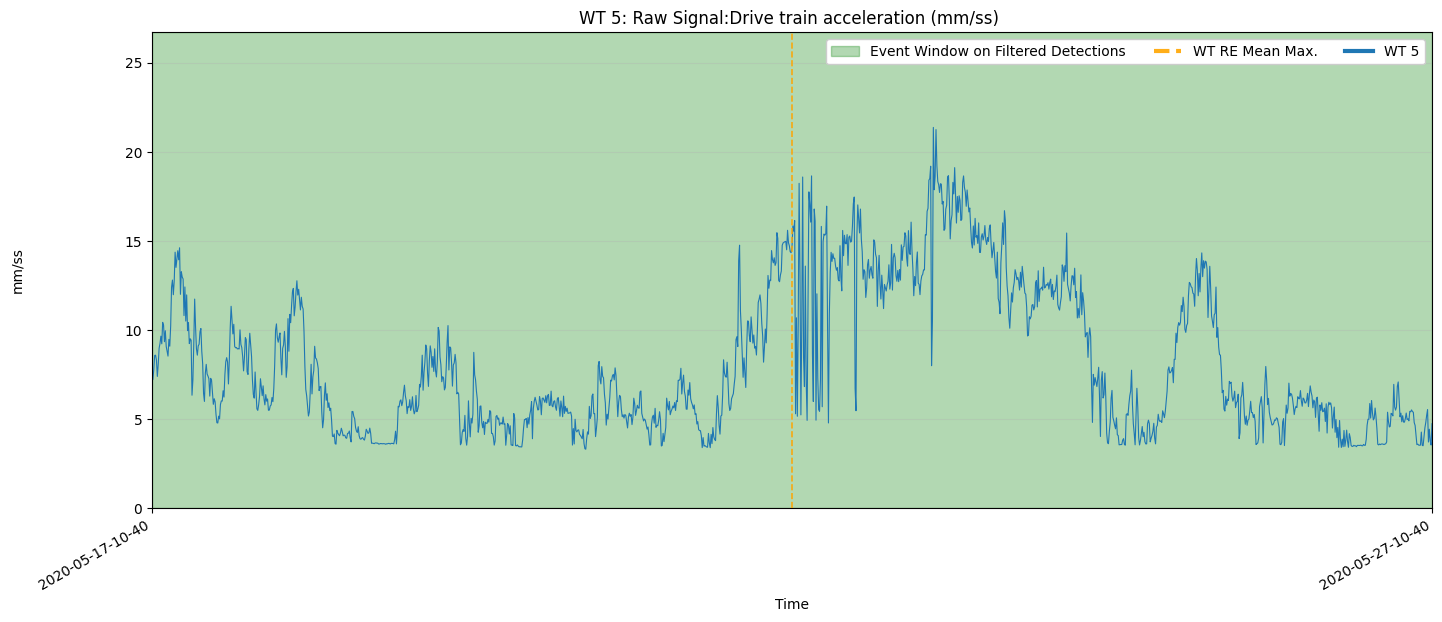

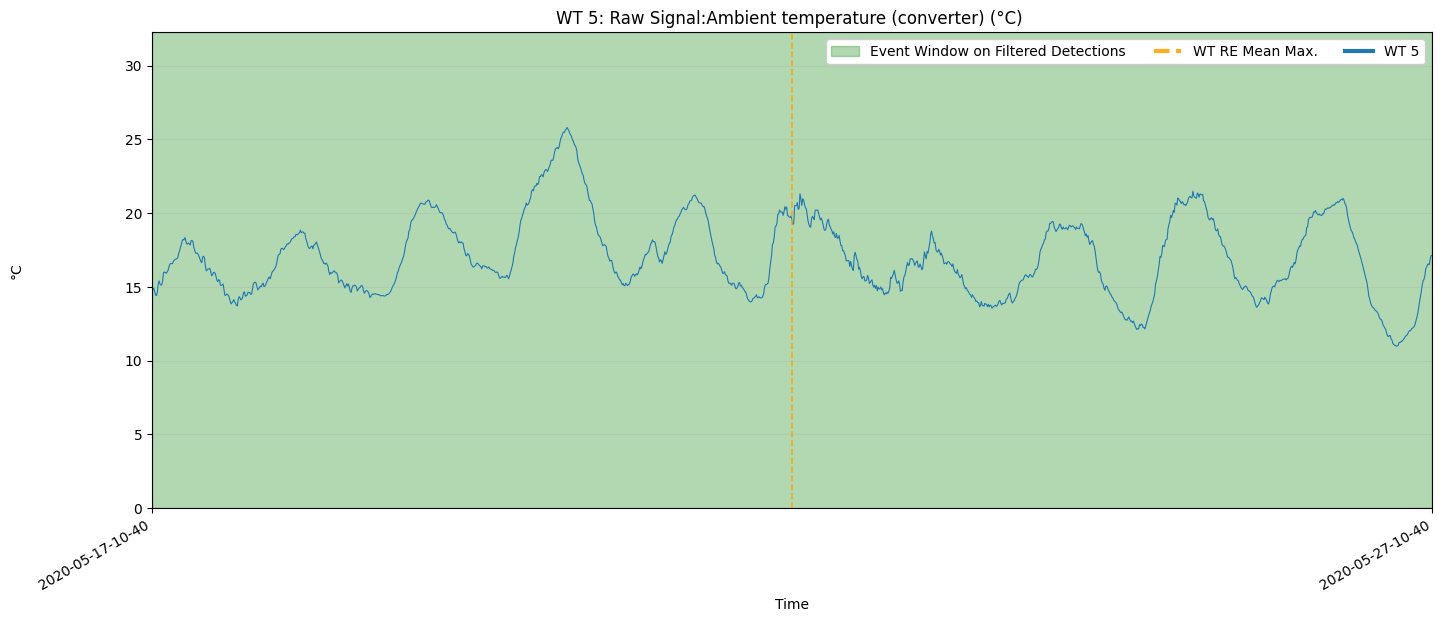

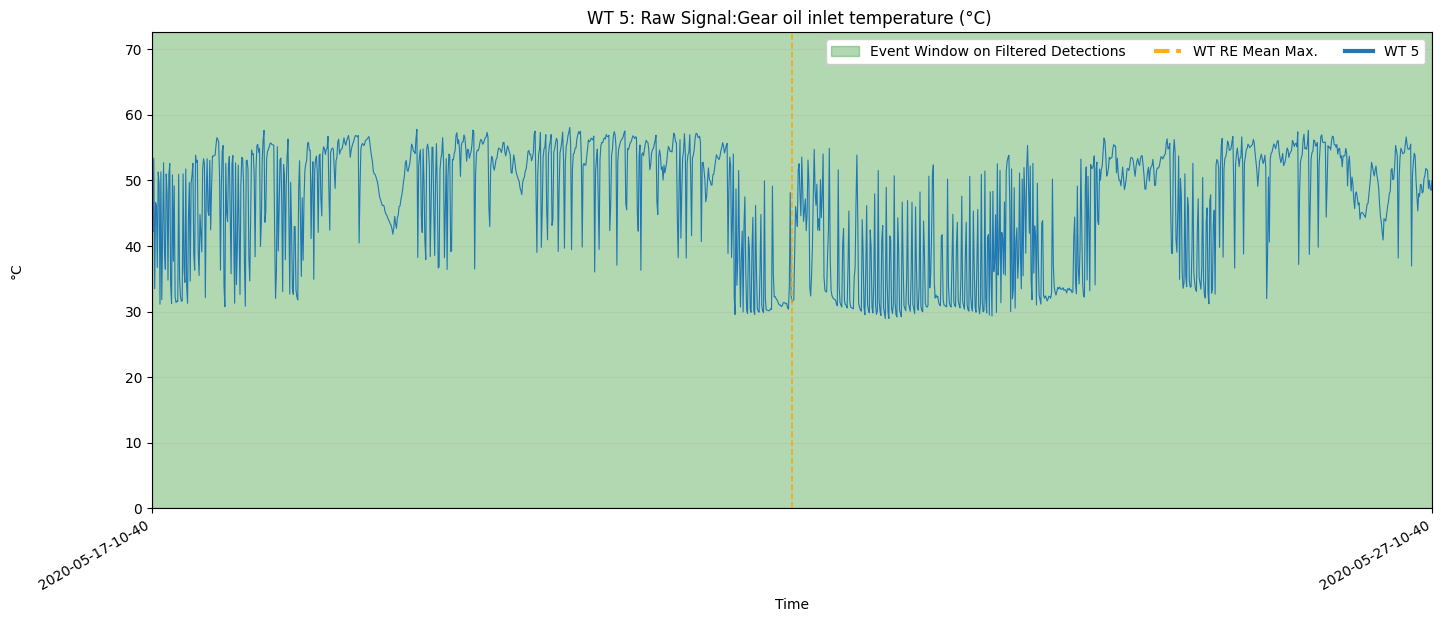

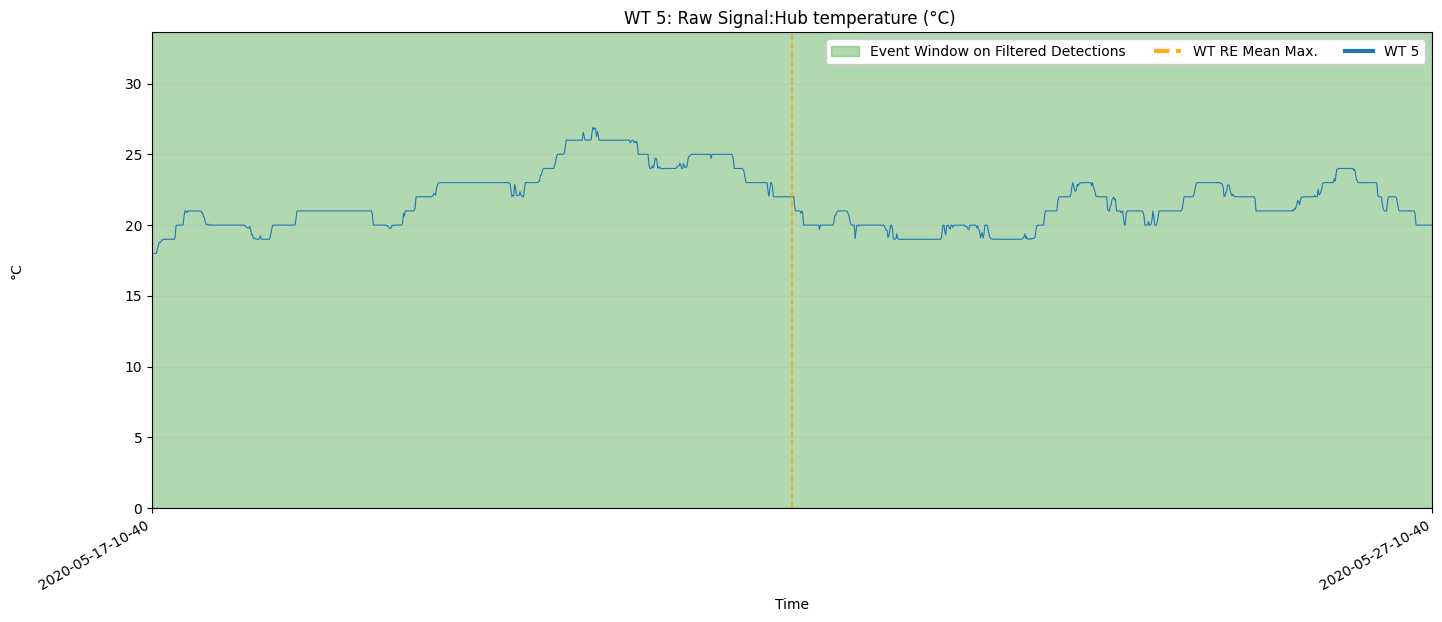

In [656]:
fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}_*")
wt_df = pd.read_csv(next(iter(fp)))

for (ts,sig) in top_sigs_no_prefix_wt:
    pp.print_loss(wt_df, 
                values=sig,
                title=f"WT {wt}: Raw Signal:{sig} ",
                wt_id=[wt],
                ts_range= (min_ts, max_ts),
                anomaly_spans=anomaly_spans_wt,
                detection_label="WT RE Mean Max.",
                detection_ts= [ts],
                y_label = pp.unit(sig),
                anom_span_label="Event Window on Filtered Detections",),
                


In [657]:
wind_col = "Wind speed (m/s)"
power_col = "Power (kW)"
df_det_keys = filtered_cat[[ic.WT_ID, ic.TS_COL]].copy()
df_det_keys2 = df_det_keys.drop_duplicates([ic.WT_ID, ic.TS_COL])
df_det_points = df_det_keys2.merge(
    wt_farm_df[[ic.WT_ID,ic.TS_COL, wind_col, power_col]],
    on=[ic.WT_ID, ic.TS_COL],
    how="left",
    validate="one_to_one"
)

df_det_points.head()

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,5,2020-05-22 10:40:00,15.279276,1900.345276


In [658]:
print(detection_ts)

2020-05-22 10:40:00


c:\Users\admin\Uni\Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\helperfunctions\pretty_print.py:866: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  t_num = t.view("int64").to_numpy()


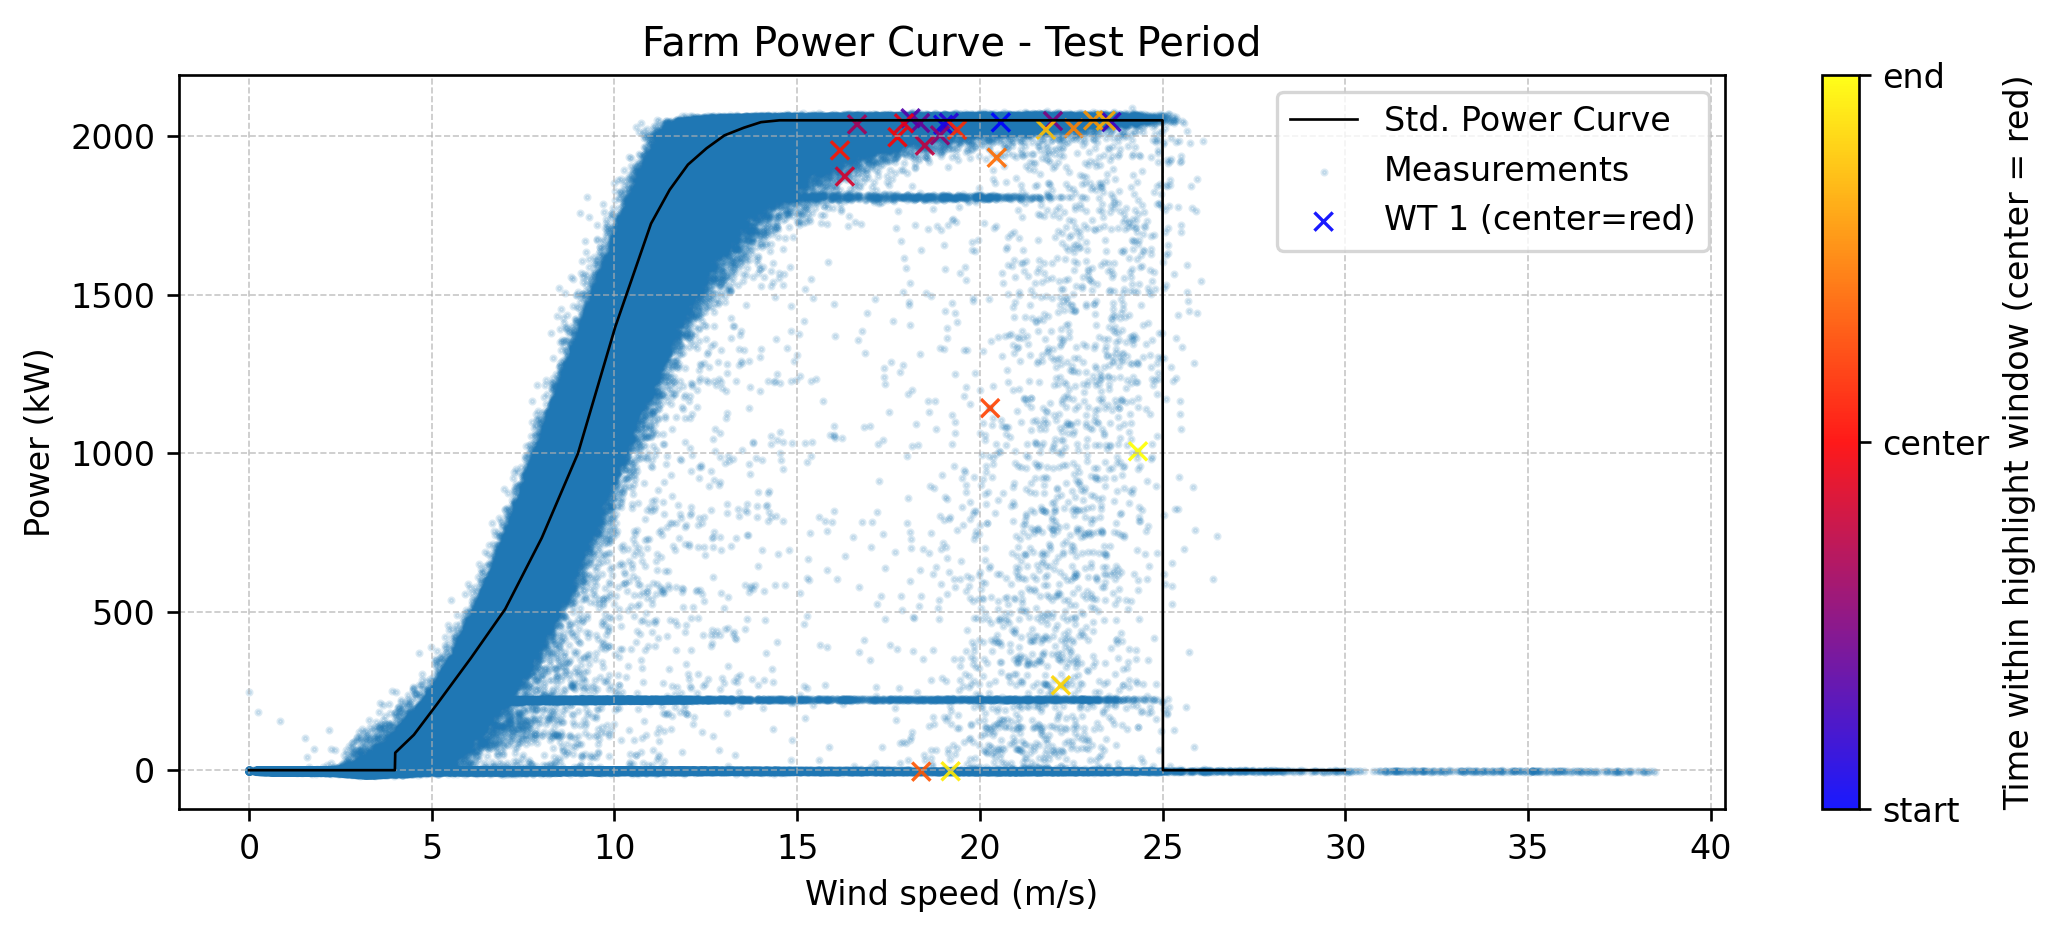

In [660]:
delta = pd.Timedelta(hours=2)
pp.print_powercurve(df_pc=df_pc,
                    df_wts=p2.drop_imputations( wt_farm_df),
                    df_detections=df_det_points[(df_det_points[ic.WT_ID]== 1) & (df_det_points[ic.TS_COL]==detection_ts )],
                    detections_label=f"Detection on WT {wt}",
                    highlight_wt=1,
                    highlight_ts_range=(pd.to_datetime(detection_ts) - delta, pd.to_datetime(detection_ts) +delta),
                    alpha_det=0.7,
                    fig_size=(9,4)
                    )

In [661]:
print(pd.to_datetime(detection_ts) +delta)

2020-05-22 12:40:00


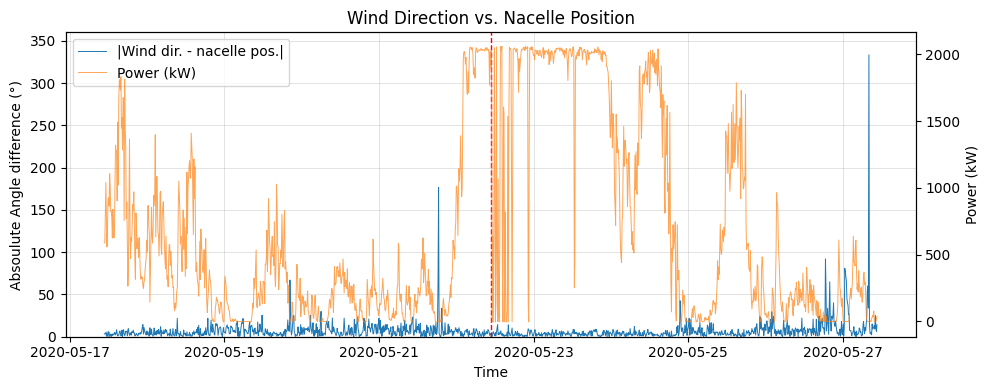

In [662]:
pp.plot_wind_vs_nacelle(df=wt_df, ts_mark=detection_ts, ts_range=(detection_ts - pd.Timedelta(days=5), detection_ts + pd.Timedelta(days=5)))

In [663]:
print(wt)

5


In [664]:
status_logs = pd.read_csv(ic.PATH_PENMANSHIEL / f"Status_Logs_Complete_ID_{wt}.csv")
status_logs["Timestamp start"] = pd.to_datetime(status_logs["Timestamp start"], errors="coerce")
status_logs["Timestamp end"] = pd.to_datetime(status_logs["Timestamp end"], errors="coerce")

In [665]:
display(status_logs.head())

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category
0,2016-06-15 18:54:11,2016-06-15 19:02:20,00:08:09,Stop,210,Manual brake,NaN,Manual stop (service) (9),Scheduled Maintenance,5,NaN,NaN
1,2016-06-15 19:03:25,2016-06-15 19:03:42,00:00:17,Stop,710,Battery test,NaN,Operating states (28),Technical Standby,5,NaN,NaN
2,2016-06-15 19:06:04,2016-06-15 19:07:54,00:01:50,Stop,1548,Missing gear oil (low rpm),NaN,Mechanical error (23),NaN,5,NaN,NaN
3,2016-06-15 19:12:13,2016-06-15 19:46:43,00:34:30,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance,5,NaN,NaN
4,2016-06-15 19:20:58,2016-06-15 19:21:32,00:00:34,Warning,3220,Reduced power converter,NaN,Warnings (27),NaN,5,NaN,NaN


In [666]:
print(detection_ts)

2020-05-22 10:40:00


In [667]:
filter = status_logs[( detection_ts >= status_logs["Timestamp start"] ) & (detection_ts <= status_logs["Timestamp end"] )]

display(filter)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category


In [668]:
delta = pd.Timedelta(hours=3)
det_start = detection_ts - delta
det_end = detection_ts + delta

In [669]:
filter = status_logs[(status_logs["Timestamp start"] <= det_end) & (status_logs["Timestamp end"] >= det_start)]
display(filter)
print(detection_ts)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category
34006,2020-05-22 11:08:36,2020-05-22 11:19:13,00:10:37,Stop,64,Max. wind speed,NaN,External stop (low wind speed) (5),Out of Environmental Specification,5,NaN,NaN
34014,2020-05-22 11:26:29,2020-05-22 11:42:43,00:16:14,Stop,64,Max. wind speed,NaN,External stop (low wind speed) (5),Out of Environmental Specification,5,NaN,NaN
34022,2020-05-22 12:06:08,2020-05-22 12:22:50,00:16:42,Stop,64,Max. wind speed,NaN,External stop (low wind speed) (5),Out of Environmental Specification,5,NaN,NaN
34030,2020-05-22 12:40:56,2020-05-22 13:00:43,00:19:47,Stop,64,Max. wind speed,NaN,External stop (low wind speed) (5),Out of Environmental Specification,5,NaN,NaN
34038,2020-05-22 13:05:44,2020-05-22 13:05:54,00:00:10,Warning,6052,High yaw motor current,NaN,Warnings (27),Full Performance,5,NaN,NaN
34040,2020-05-22 13:10:22,2020-05-22 13:31:24,00:21:02,Stop,64,Max. wind speed,NaN,External stop (low wind speed) (5),Out of Environmental Specification,5,NaN,NaN


2020-05-22 10:40:00


In [584]:
raw_test = pd.read_csv(ic.PATH_PART2_RAW_TEST / "raw_test.csv", parse_dates=[ic.TS_COL])

In [585]:
date = detection_ts

Ambient temperature (converter) (°C)
Generator bearing front temperature (°C)
Generator bearing rear temperature (°C)
Hub temperature (°C)
Nacelle ambient temperature (°C)
Nacelle temperature (°C)
Rotor bearing temp (°C)
Stator temperature 1 (°C)
Temp. top box (°C)
Temperature motor axis 1 (°C)
Temperature motor axis 2 (°C)
Temperature motor axis 3 (°C)
Front bearing temperature (°C)
Gear oil inlet temperature (°C)
Gear oil temperature (°C)
Rear bearing temperature (°C)
Transformer cell temperature (°C)
Transformer temperature (°C)
Power (kW)


c:\Users\admin\Uni\Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\helperfunctions\pretty_print.py:1346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


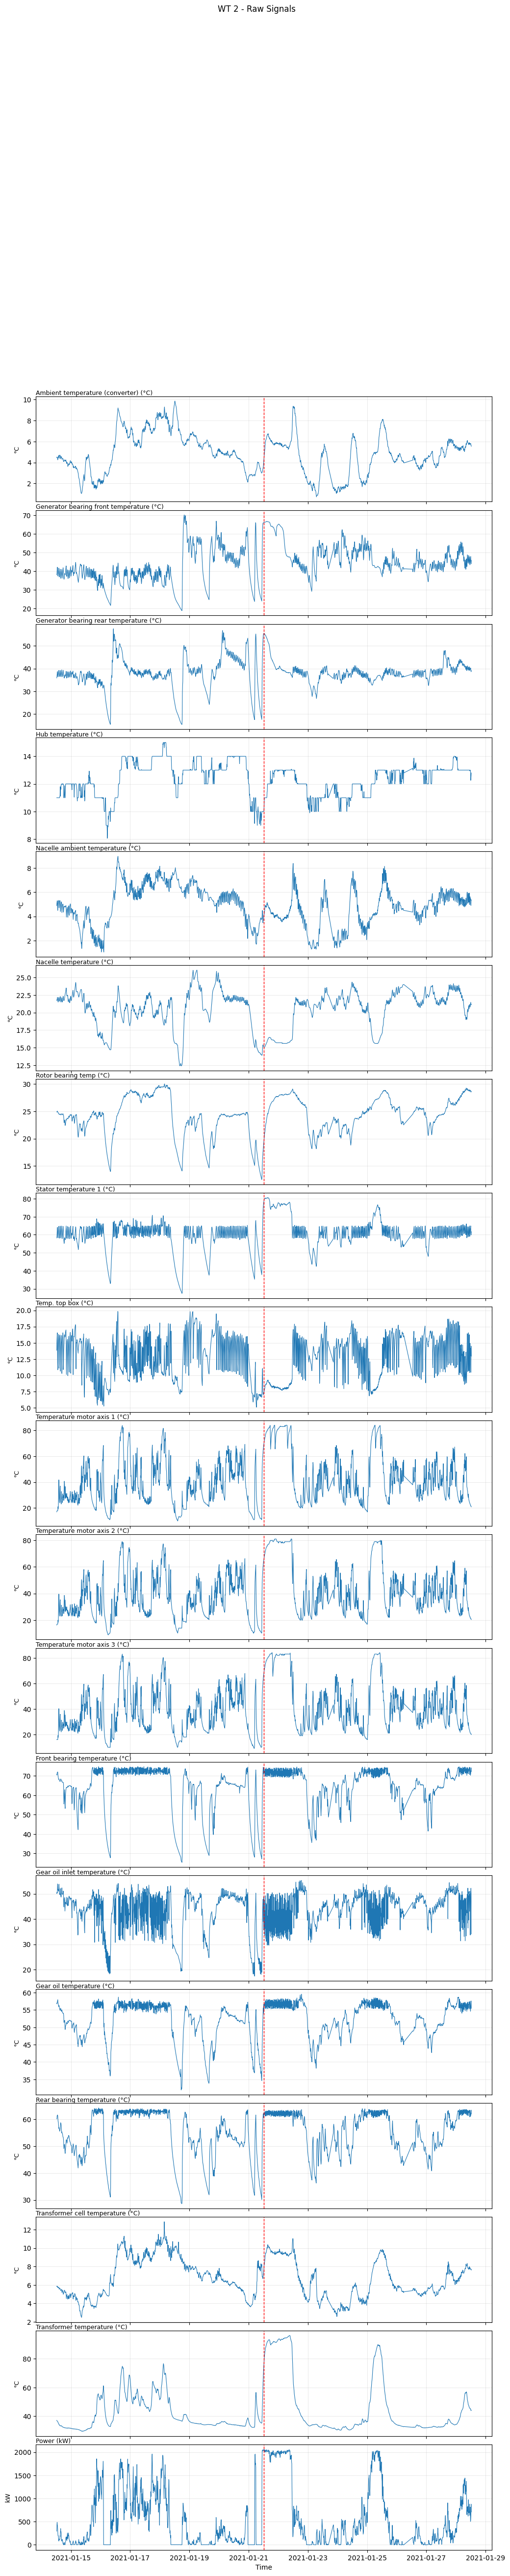

In [134]:
signals = [sig for sig in hfn.load_feature_order() if "(°C)" in sig] + ["Power (kW)"]
for sig in signals:
    print(sig)
    
pp.plot_signals_compact(df=raw_test,
                        wt_id = wt,
                        signals=signals,
                        anomaly_spans= None,
                        fig_size=(12,3),
                        ts_mark=[detection_ts],
                        ts_range=(detection_ts- pd.Timedelta(days=7),detection_ts + pd.Timedelta(days=7))
                        )

Drive train acceleration (mm/ss)
Gear oil inlet pressure (bar)
Gear oil pump pressure (bar)
Gearbox speed (RPM)
Generator RPM (RPM)
Motor current axis 1 (A)
Motor current axis 2 (A)
Motor current axis 3 (A)
Nacelle position (°)
Power (kW)
Rotor speed (RPM)
Vane position 1+2 (°)
Wind direction (°)
Wind speed (m/s)
Blade angle (pitch position) A (°)
Blade angle (pitch position) B (°)
Blade angle (pitch position) C (°)
Tower Acceleration X (mm/ss)
Tower Acceleration Y (mm/ss)
Yaw bearing angle (°)


c:\Users\admin\Uni\Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\helperfunctions\pretty_print.py:1346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


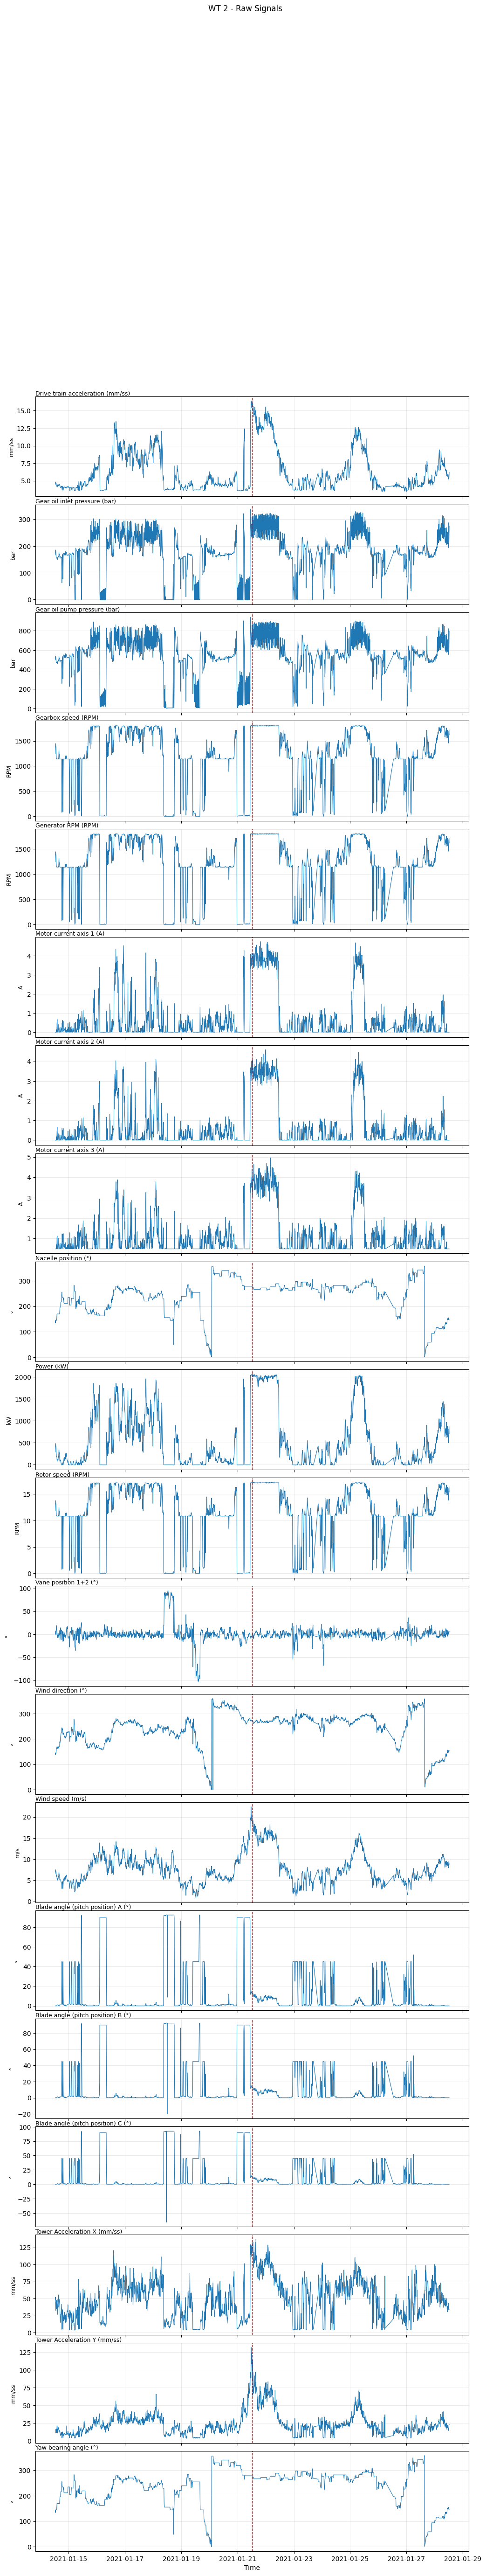

In [135]:
signals = [sig for sig in hfn.load_feature_order() if "(°C)" not in sig]
for sig in signals:
    print(sig)
    
pp.plot_signals_compact(df=raw_test,
                        wt_id = wt,
                        signals=signals,
                        anomaly_spans= None,
                        fig_size=(12,3),
                        ts_mark=date,
                        ts_range=(date - pd.Timedelta(days=7), date + pd.Timedelta(days=7))
                        )